In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/tabela_base_traduzida.csv')

# Análise exploratória (EDA)

---

#### Este arquivo é responsável pela análise explorátoria (EDA) dos dados tratados, é por meio dele que irkemos conhecer os dados que estamos trabalhando e quais análises poderemos realizar

## Perguntas e variáveis análisadas

- Taxa global de atrito: Quantas pessoas saíram vs quantas continuam na empresa
- Taxa de atrito por gênero
- Áreas com maiores perdas de funcionários
- Cargos com mais pedidos de demissão
- Funcionários com menos tempo de casa saem mais ? Isso afeta diretamente o cargo ?
- Pedidos de demissão vs Salário e benefícios
- Carga de hora trabalhada | Quem costuma fazer hora extra costuma sair mais ?
- Satisfação geral no trabalho vs Pedidos de demissão
- Distância do trabalho vs pedidos de demissão
- Viagens a negócio interferem nos pedidos de demissão ?

---

# Código:

- Taxa global de atrito: Quantas pessoas saíram vs quantas continuam na empresa

In [11]:
ativos = df.groupby(df["Demitido"] == "No").size()
demitidos = df.groupby(df["Demitido"] == "Yes").size()

p_ativos = ativos[True] / (ativos[True] + demitidos[True]) * 100
p_demitidos = demitidos[True] / (ativos[True] + demitidos[True]) * 100

print(f"A empresa possui {p_ativos:.2f}% de funcionários ativos e {p_demitidos:.2f}% de funcionários demitidos. Os valores absolutos são {ativos[True]} funcionários ativos e {demitidos[True]} funcionários demitidos.")

A empresa possui 83.88% de funcionários ativos e 16.12% de funcionários demitidos. Os valores absolutos são 1233 funcionários ativos e 237 funcionários demitidos.


- Taxa de atrito por gênero

Dentre os demitidos, que representam 16.12% do total de registros, 10.20% são do gênero masculino e 5.92% são do gênero feminino. Os valores absolutos são 150 demitidos do gênero masculino e 87 demitidos do gênero feminino.


Text(0, 0.5, 'Número de Funcionários')

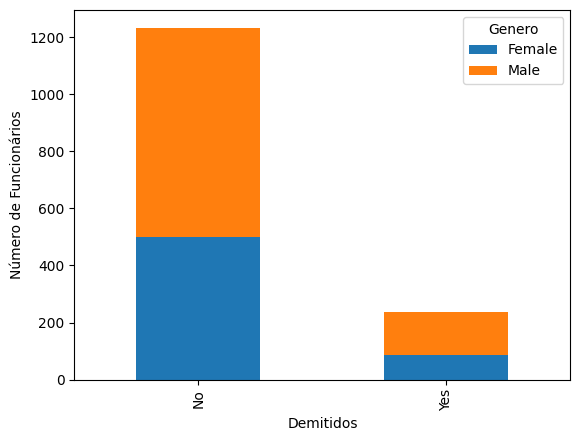

In [28]:
demitidos_genero = df.groupby(["Demitido", "Genero"]).size()

linhas_masculinas = len(df["Genero"] == "Male")
linhas_femininas = len(df["Genero"] == "Female")

demitidos_masculino = demitidos_genero[("Yes", "Male")]
demitidos_feminino = demitidos_genero[("Yes", "Female")]

numero_linhas = len(df)

p_masculino = demitidos_masculino / linhas_masculinas * 100
p_feminino = demitidos_feminino / linhas_femininas * 100

soma_p = p_masculino + p_feminino

print(f"Dentre os demitidos, que representam {soma_p:.2f}% do total de registros, {p_masculino:.2f}% são do gênero masculino e {p_feminino:.2f}% são do gênero feminino. Os valores absolutos são {demitidos_masculino} demitidos do gênero masculino e {demitidos_feminino} demitidos do gênero feminino.")

demitidos_genero.unstack().plot(kind="bar", stacked=True, ax=plt.gca())
plt.xlabel("Demitidos")
plt.ylabel("Número de Funcionários")

- Áreas com maiores perdas de funcionários

Departamento
Sales                     6959.17
Human Resources           6654.51
Research & Development    6281.25
Name: Renda_Mensal, dtype: float64

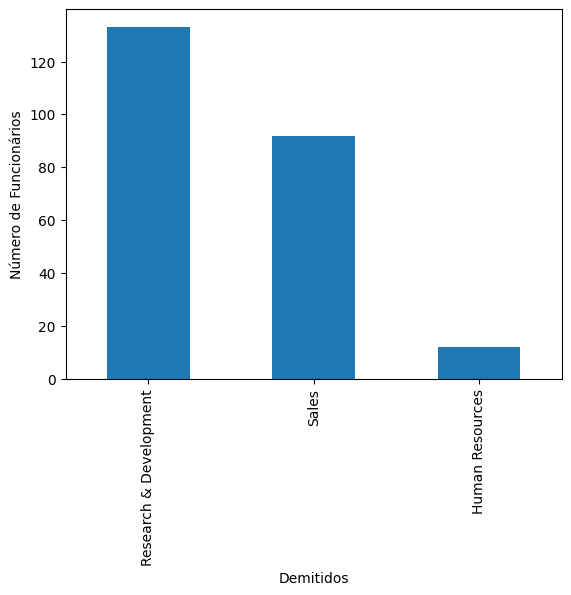

In [61]:
perda_departamento = df.groupby([df["Demitido"] == "Yes", "Departamento"]).size()
media_salarios_departamento = df.groupby("Departamento")["Renda_Mensal"].mean()


perda_departamento[True].sort_values(ascending = False).plot(kind="bar", stacked=True, ax=plt.gca())
plt.xlabel("Demitidos")
plt.ylabel("Número de Funcionários")

media_salarios_departamento.round(2).sort_values(ascending = False)

- Cargos com mais pedidos de demissão

Cargo
Manager                      17181.68
Research Director            16033.55
Healthcare Representative     7528.76
Manufacturing Director        7295.14
Sales Executive               6924.28
Human Resources               4235.75
Research Scientist            3239.97
Laboratory Technician         3237.17
Sales Representative          2626.00
Name: Renda_Mensal, dtype: float64

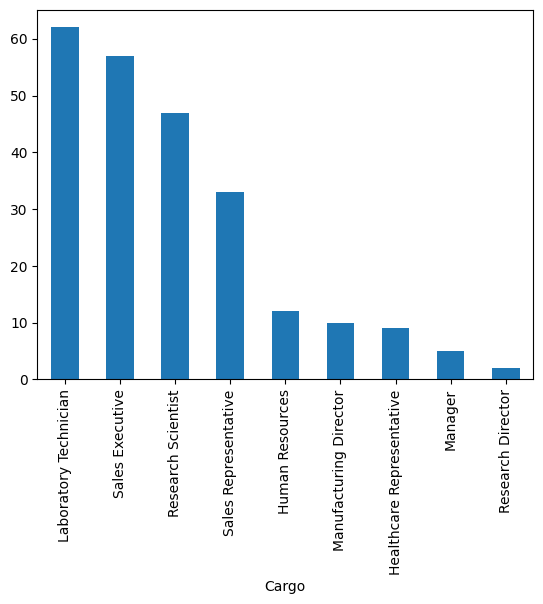

In [27]:
media_salarios_cargo = df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).round(2)
demitidos_cargo = df[df["Demitido"] == "Yes"].groupby("Cargo").size()

demitidos_cargo.sort_values(ascending = False).plot(kind="bar", label="Demitidos")
media_salarios_cargo

- Funcionários com menos tempo de casa saem mais ? Isso afeta diretamente o cargo ?

Text(0, 0.5, 'Número de Funcionários Demitidos')

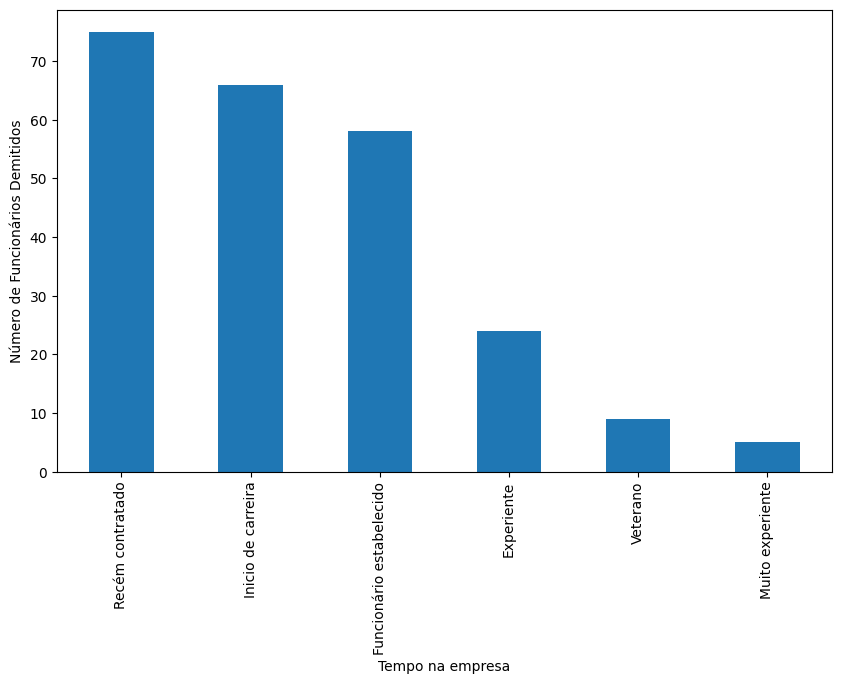

In [66]:
faixa_tempo = df.groupby([df["Demitido"] == "Yes", "Faixa_de_tempo_empresa"]).size()
plt.figure(figsize=(10, 6))
faixa_tempo[True].sort_values(ascending = False).plot(kind="bar", ax=plt.gca())
plt.xlabel("Tempo na empresa")
plt.ylabel("Número de Funcionários Demitidos")

Text(0, 0.5, 'Número de Funcionários Demitidos')

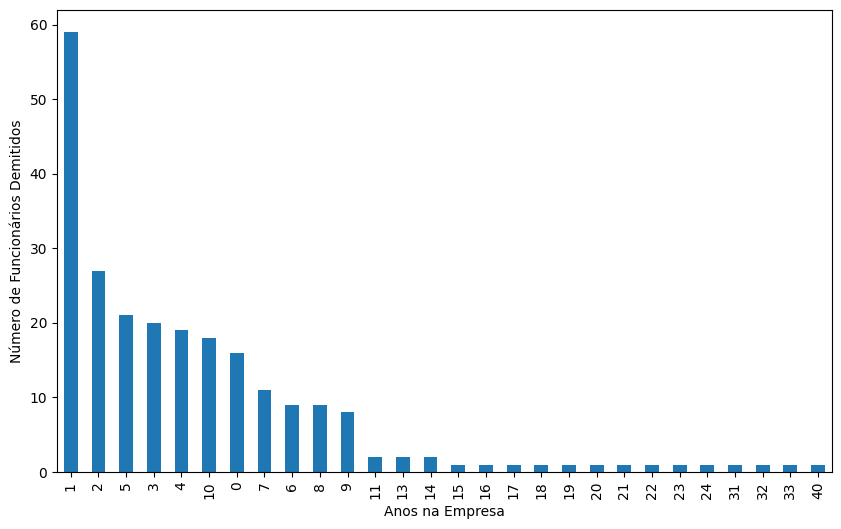

In [50]:
tempo_na_empresa = df.groupby([df["Demitido"] == "Yes", "Anos_na_Empresa"]).size()

plt.figure(figsize=(10, 6))
tempo_na_empresa[True].sort_values(ascending = False).plot(kind="bar", ax=plt.gca())
plt.xlabel("Anos na Empresa")
plt.ylabel("Número de Funcionários Demitidos")

Média de anos trabalhados na empresa por cargo:
Cargo
Manager                      14.43
Research Director            10.94
Healthcare Representative     8.37
Manufacturing Director        7.60
Sales Executive               7.50
Human Resources               5.33
Research Scientist            5.11
Laboratory Technician         5.02
Sales Representative          2.92
Name: Anos_na_Empresa, dtype: float64
Média de salário por cargo:


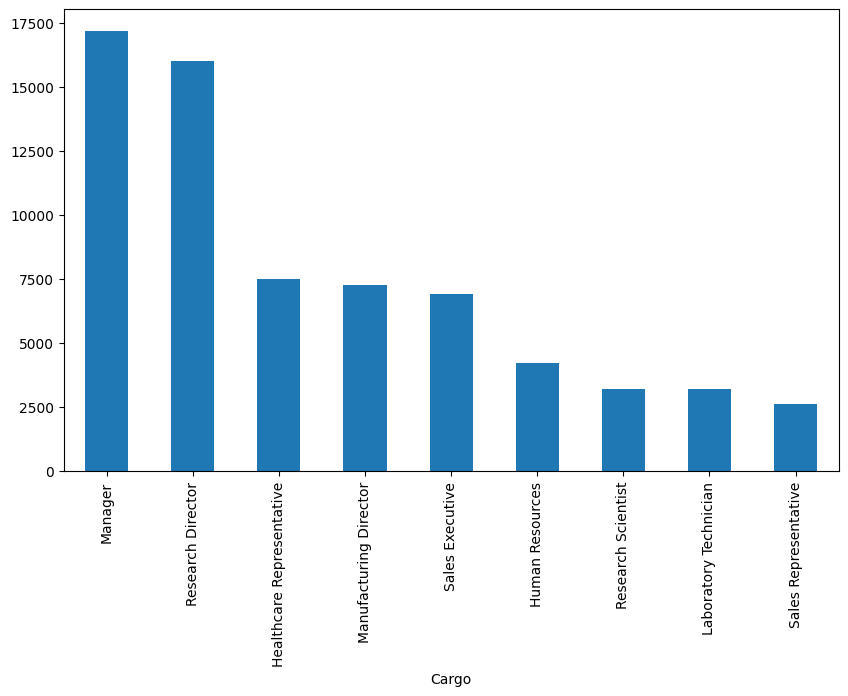

In [49]:
tempo_na_empresa = df.groupby([df["Demitido"] == "Yes", "Cargo", "Anos_na_Empresa"]).size()
media_tempo_cargo = df.groupby("Cargo")["Anos_na_Empresa"].mean().sort_values(ascending=False).round(2)

plt.figure(figsize=(10, 6))
media_salarios_cargo.sort_values(ascending = False).plot(kind="bar", label="Média de Salário")

print("Média de anos trabalhados na empresa por cargo:")
print(media_tempo_cargo)
print("Média de salário por cargo:")

- Pedidos de demissão vs Salário e benefícios

Média de salário por cargo:

Cargo
Manager                      17181.68
Research Director            16033.55
Healthcare Representative     7528.76
Manufacturing Director        7295.14
Sales Executive               6924.28
Human Resources               4235.75
Research Scientist            3239.97
Laboratory Technician         3237.17
Sales Representative          2626.00
Name: Renda_Mensal, dtype: float64


Text(0.5, 1.0, 'Número de Pedidos de Demissão por Cargo')

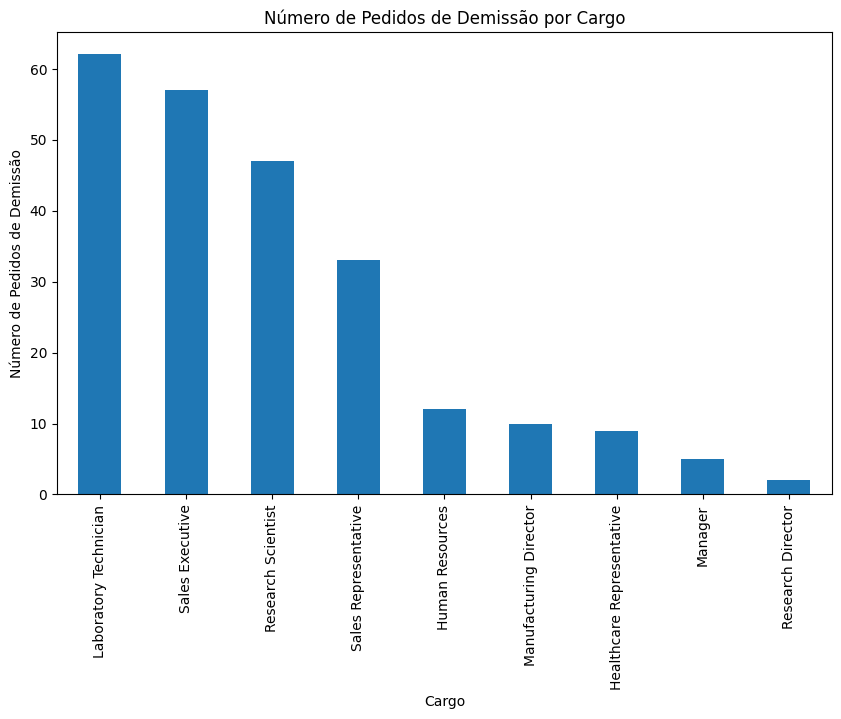

In [48]:
pedidos_de_demissao = df[df["Demitido"] == "Yes"].groupby("Cargo").size()
media_salarios_cargo = df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).round(2)


print(f"Média de salário por cargo:\n\n{media_salarios_cargo}")

plt.figure(figsize=(10, 6))
pedidos_de_demissao.sort_values(ascending=False).plot(kind="bar", label="Pedidos de Demissão")
plt.xlabel("Cargo")
plt.ylabel("Número de Pedidos de Demissão")
plt.title("Número de Pedidos de Demissão por Cargo")



- Carga de hora trabalhada | Quem costuma fazer hora extra costuma sair mais ?


Hora_Extra
Yes    127
No     110
dtype: int64

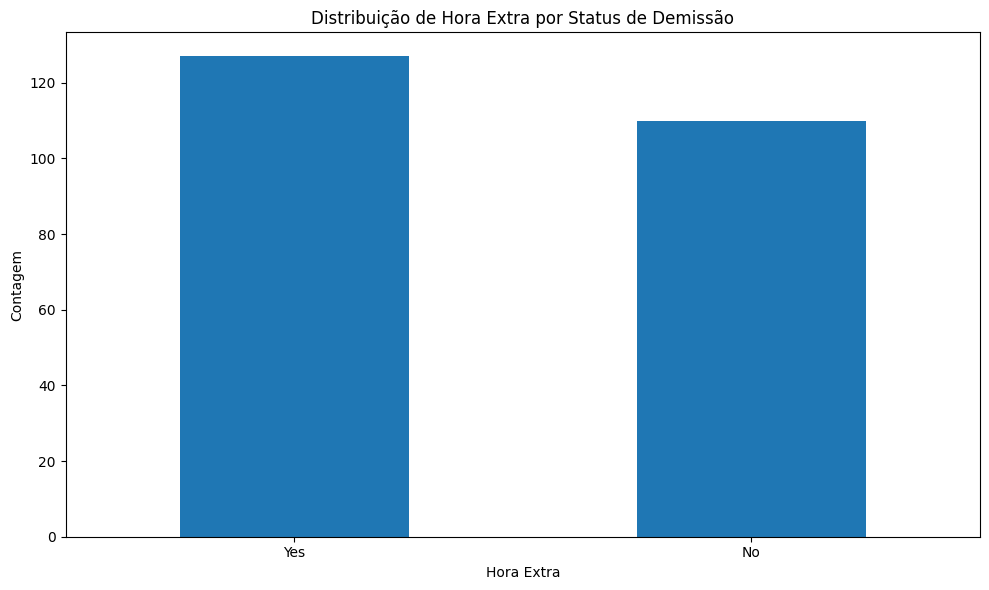

In [92]:
hora_extra = df.groupby([df["Demitido"] == "Yes", "Hora_Extra"]).size()



plt.figure(figsize=(10, 6))
hora_extra[True].sort_values(ascending = False).plot(kind="bar", ax=plt.gca())
plt.xlabel("Hora Extra")
plt.ylabel("Contagem")
plt.title("Distribuição de Hora Extra por Status de Demissão")
plt.xticks(rotation=0)
plt.tight_layout()

hora_extra[True].sort_values(ascending = False)

- Satisfação geral no trabalho vs Pedidos de demissão

Média de satisfação geral:

Ativos: 102.75
Demitidos: 19.75


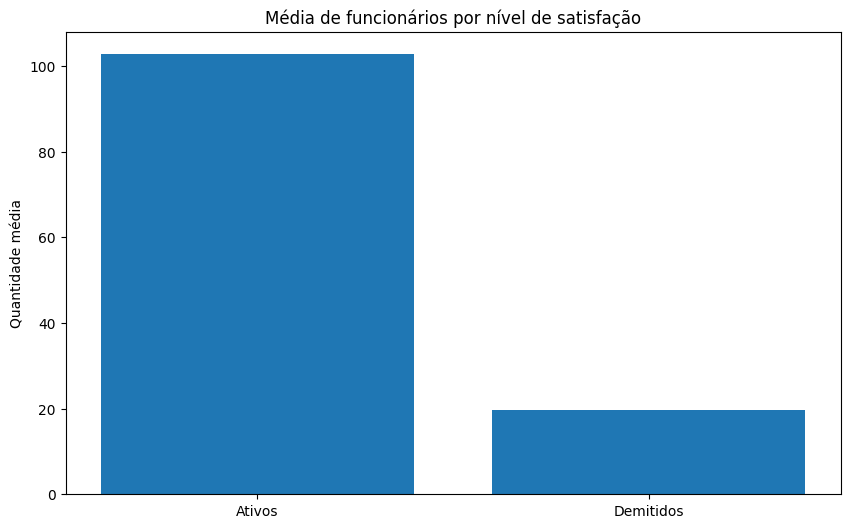

In [ ]:
agrupado = df.groupby([df["Demitido"] == "Yes", "Satisfação_geral"]).size()

ativos = agrupado[False].mean()
demitidos = agrupado[True].mean()

print(f"Média de satisfação geral:\n\nAtivos: {ativos}\nDemitidos: {demitidos}")

plt.figure(figsize=(10, 6))
plt.bar(["Ativos", "Demitidos"], [ativos, demitidos])

plt.title("Média de funcionários por nível de satisfação")
plt.ylabel("Quantidade média")


- Distância do trabalho vs pedidos de demissão


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Muito próxima'),
  Text(1, 0, 'Próxima'),
  Text(2, 0, 'Muito distantew'),
  Text(3, 0, 'Moderada'),
  Text(4, 0, 'Distante')])

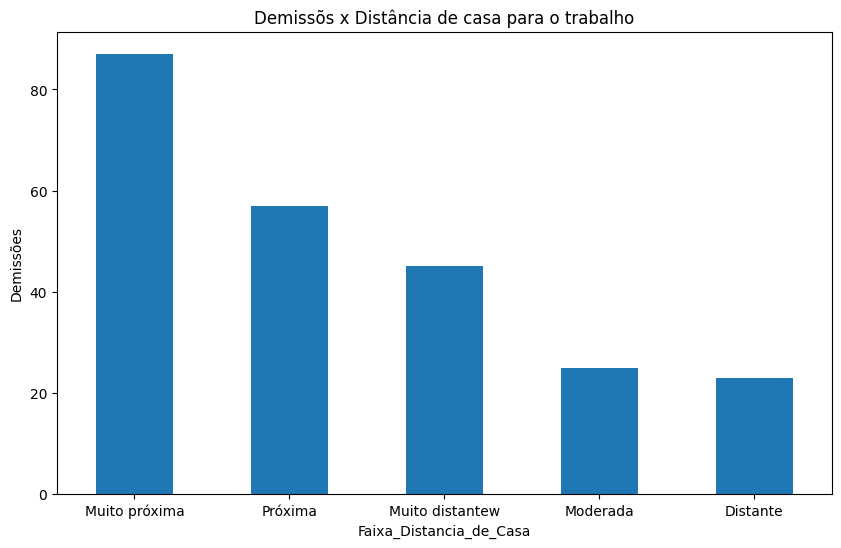

In [143]:
agrupado = df.groupby([df["Demitido"] == "Yes", df["Faixa_Distancia_de_Casa"]]).size()

plt.figure(figsize = (10,6))
plt.title("Demissõs x Distância de casa para o trabalho")
plt.xlabel("Distância")
plt.ylabel("Demissões")
agrupado[True].sort_values(ascending = False).plot(kind = "bar")
plt.xticks(rotation = 0)


In [132]:
df.columns

Index(['Idade', 'Demitido', 'Viagens_a_Negocio', 'Valor_Diaria',
       'Departamento', 'Distancia_de_Casa', 'Escolaridade', 'Area_de_Formacao',
       'Contagem_de_Funcionarios', 'ID_Funcionario', 'Satisfacao_com_Ambiente',
       'Genero', 'Valor_Hora', 'Envolvimento_com_Trabalho', 'Nivel_do_Cargo',
       'Cargo', 'Satisfacao_com_Trabalho', 'Estado_Civil', 'Renda_Mensal',
       'Valor_Mensal', 'Numero_de_Empresas_Anteriores', 'Maior_de_18',
       'Hora_Extra', 'Percentual_Aumento_Salario', 'Avaliacao_Desempenho',
       'Satisfacao_Relacionamento', 'Horas_Padrao', 'StockOptionLevel',
       'Total_Anos_Trabalhados', 'Treinamentos_Ano_Passado',
       'Equilibrio_Vida_Trabalho', 'Anos_na_Empresa', 'Anos_no_Cargo_Atual',
       'Anos_Desde_Ultima_Promocao', 'Anos_com_Gerente_Atual', 'Faixa_Etaria',
       'Faixa_de_tempo_empresa', 'Razão_salarial', 'Satisfação_geral',
       'Faixa_Distancia_de_Casa)'],
      dtype='object')

- Viagens a negócio interferem nos pedidos de demissão ?


(array([0, 1, 2]),
 [Text(0, 0, 'Travel_Rarely'),
  Text(1, 0, 'Travel_Frequently'),
  Text(2, 0, 'Non-Travel')])

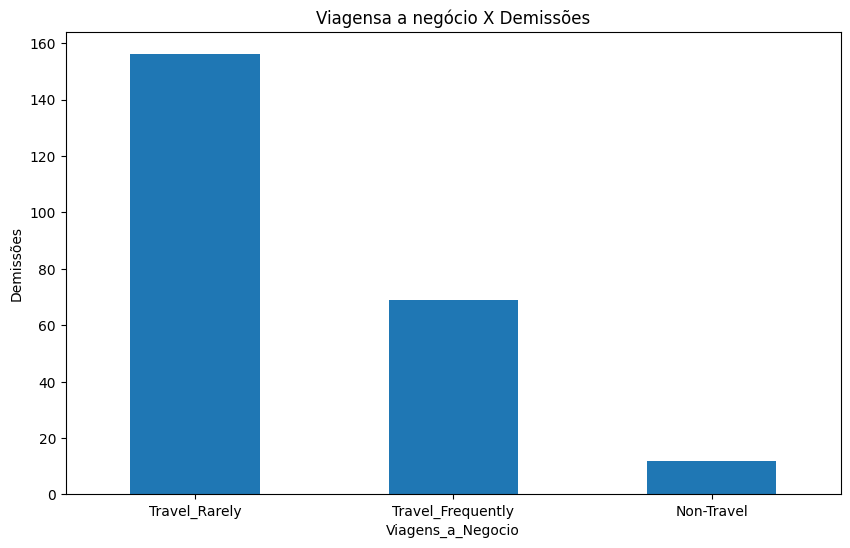

In [122]:
agrupado_distancia = df.groupby([df["Demitido"] == "Yes", "Viagens_a_Negocio"]).size()
agrupado_distancia[True]

plt.figure(figsize = (10,6))
plt.xlabel("Frequência")
plt.ylabel("Demissões")
plt.title("Viagensa a negócio X Demissões")
agrupado_distancia[True].sort_values(ascending = False).plot(kind = "bar")
plt.xticks(rotation=0)




---

> arrumar código a partir daqui

- Anotações

Após realizar a análise exploratória, segue minhas anotações de alguns dados percebidos:

---

Variáveis analisadas até o instante:

01. Demitidos por Gênero
02. Demitidos por Faxetária de Idade
03. Demitidos por Cargo

---

01. Demitidos por Gênero:

A maior taxa de demissão por gênero é masculina, a análise apresenta que 17,01% dos homens foram demitidos, enquanto para mulheres, as demissões representam 17,8%

02. Demitidos por faxetaria de idade:

A maior parte dos demitidos são adultos 46,41% (30 - 44 anos), seguidos por jovens 38,40% (18 - 29 anos), e por último, maduros 15,19% (45-59 anos)

03. Demitidos por cargo: 

A maior quantidade de cargos demitidos são os técnicos de laborátório que, mesmo representando o maior número de cargos (259) só representa 8% do total gasto pela empresa em salários
Em contra partida, os que menos possuem demissões são os Diretores de Pesquisas (80) e os Técnicos (102), que por suas vezes, representam 13,42% e 18,43% do mesmo total gasto em salário 


